In [1]:
%%capture
!pip install ftfy regex tqdm
# !pip install torch==2.7.1 torchvision==0.22.1 cuda-bindings==12.9.* # P100 uses old cuda (sm-60)
!pip install --no-deps git+https://github.com/openai/CLIP.git
!pip install --no-deps retina-face

In [2]:
from pathlib import Path
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import gc
from typing import Tuple, List, Iterator

from retinaface import RetinaFace
from skimage import transform
from sklearn.metrics import roc_curve
import clip
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from torchmetrics import AUROC
import kornia.geometry as K

2026-07-06 22:27:31.621535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783376852.122709      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783376852.244962      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783376853.326203      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783376853.326246      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783376853.326248      24 computation_placer.cc:177] computation placer alr

In [3]:
torch.manual_seed(42)
np.random.seed(42)

# Datapaths.
DATA_DIR = Path("/kaggle/input/datasets/ahmedelbanby/faceforensicsplusplus-c23-deepfakebench-structure/videos/FaceForensics++")
ORIGINAL_DATA_DIR = DATA_DIR / "original_sequences" / "youtube" / "c23" / "videos"
TEST_DATA_DIR = Path("/kaggle/input/datasets/pranay22077/dfdc-10")
OUT_DIR = Path("/kaggle/working/train")
MODEL_CKPT = Path("/kaggle/input/models/loubl00m/deepfaker/pytorch/default/1/best_model.pt")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Data and train params.
DEEPFAKE_METHODS = ["Deepfakes", "Face2Face", "FaceShifter", "FaceSwap"]
N_DATA = 1000 # Number of examples per method.
N_TEST = 1000 # Number of test videos per class.
TOTAL_FRAMES = 8
IMG_DIMS = (224, 224)
SCALE = 1.3
BATCH_SIZE = 8
DEVICE = torch.device("cpu" if not torch.cuda.is_available() else f"cuda:{torch.cuda.device_count()-1}")
DTYPE = torch.float32

## Data preprocessing

In [4]:
def get_pairs_ff(datapath: Path) -> List[Tuple[Path, Path]]:
    """
    Pairs each fake video from the path with its real counterpart.
    Args:
        datapath: Directory containing manipulated videos.

    Returns:
        A list of ``(fake_video, real_video)`` path pairs.
    """
    return [(x, ORIGINAL_DATA_DIR / (x.stem[:x.stem.find("_")] + ".mp4")) for x in datapath.iterdir()]


data_part = DATA_DIR / "manipulated_sequences" / DEEPFAKE_METHODS[0] / "c23" / "videos"
videos = {DEEPFAKE_METHODS[0]: get_pairs_ff(data_part)}

n = len(videos[DEEPFAKE_METHODS[0]])
print(f"There are {n} deepfake videos in the training dataset.")

There are 1000 deepfake videos in the training dataset.


In [5]:
# choose N_DATA random indices without replacement from 1 method.
# We then get all the others methods and the real video for those chosen videos.
chosen_indices = np.random.permutation(n)[:N_DATA]
chosen_pairs = [videos[DEEPFAKE_METHODS[0]][i] for i in chosen_indices]

# recuperate the paths of the other fake methods from the first one and add in the real video paths.
videos = [Path(str(x).replace(DEEPFAKE_METHODS[0], method)) for x, y in chosen_pairs
        for method in DEEPFAKE_METHODS] + [y for _, y in chosen_pairs]

In [6]:
def sample_video(path: Path | str, n_frames: int = TOTAL_FRAMES) -> np.ndarray:
    """
    Samples frames uniformly from a video file.
    Args:
        path: Path to the input video file.
        n_frames: Number of frames to sample uniformly from the video.

    Returns:
        A NumPy array of shape ``(n_frames, H, W, 3)`` containing the sampled
        RGB frames.

    Raises:
        AssertionError: If a frame cannot be read before the expected number of
            samples has been collected.
    """

    cap = cv2.VideoCapture(path)
    skip_rate = round(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // n_frames
    frames = []
    i = 0

    while i<(n_frames*skip_rate):
        ret, frame = cap.read()
        assert ret
    
        if i%skip_rate == 0:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
        i += 1
    
    cap.release()

    return np.stack(frames)

In [7]:
def similarity_transform(src: torch.Tensor, dst: torch.Tensor) -> torch.Tensor:
    """
    src, dst: (N, P, 2) tensors
    Returns M: (N, 2, 3) similarity transform matrices
    """
    n = src.shape[1]
    src_mean = src.mean(dim=1, keepdim=True)   # (N,1,2)
    dst_mean = dst.mean(dim=1, keepdim=True)   # (N,1,2)
    src_c = src - src_mean                     # (N,P,2)
    dst_c = dst - dst_mean                     # (N,P,2)

    cov = torch.einsum('npi,npj->nij', dst_c, src_c) / n   # (N,2,2)

    U, S, Vt = torch.linalg.svd(cov)                        # batched SVD
    det = torch.linalg.det(cov)                             # (N,)

    N = cov.shape[0]
    D = torch.eye(2, device=cov.device, dtype=cov.dtype).unsqueeze(0).repeat(N, 1, 1)  # (N,2,2)
    D[det < 0, 1, 1] = -1

    R = U @ D @ Vt                                          # (N,2,2)

    var_src = (src_c ** 2).sum(dim=(1, 2)) / n              # (N,)

    scale = (S * torch.diagonal(D, dim1=1, dim2=2)).sum(dim=1) / var_src  # (N,)

    t = dst_mean[:, 0, :] - scale.unsqueeze(1) * torch.einsum(
        'nij,nj->ni', R, src_mean[:, 0, :]
    )

    M = torch.cat(
        [scale.view(-1, 1, 1) * R, t.unsqueeze(-1)],
        dim=2
    )  # (N,2,3)

    return M

def img_align_crop(img: np.ndarray, landmark: np.ndarray = None,
                   outsize : Tuple[int, int] | None = None, scale: float = 1.3) -> np.ndarray:
    """ 
    align and crop the face according to the given bbox and landmarks
    landmark: 5 key points

    Args:
        img: Input image as a NumPy array.
        landmark: Array of shape ``(5, 2)`` containing the facial landmarks
            (left eye, right eye, nose tip, left mouth corner, right mouth
            corner).
        outsize: Output image size as ``(height, width)``.
        scale: Scaling factor applied to the reference face template before
            alignment. Values greater than ``1.0`` increase the margin around
            the face.

    Returns:
        The aligned face image as a NumPy array of shape ``outsize``.

    Raises:
        AttributeError: If ``landmark`` is ``None``.
        TypeError: If ``outsize`` is ``None`` or is not subscriptable.
        cv2.error: If OpenCV fails to estimate or apply the affine transform.
    """

    M = None
    target_size = [112, 112]
    dst = torch.tensor([
        [30.2946, 51.6963],
        [65.5318, 51.5014],
        [48.0252, 71.7366],
        [33.5493, 92.3655],
        [62.7299, 92.2041]], dtype=torch.float32)

    if target_size[1] == 112:
        dst[:, 0] += 8.0

    dst[:, 0] = dst[:, 0] * outsize[0] / target_size[0]
    dst[:, 1] = dst[:, 1] * outsize[1] / target_size[1]

    target_size = outsize

    margin_rate = scale - 1
    x_margin = target_size[0] * margin_rate / 2.
    y_margin = target_size[1] * margin_rate / 2.

    # move
    dst[:, 0] += x_margin
    dst[:, 1] += y_margin

    # resize
    dst[:, 0] *= target_size[0] / (target_size[0] + 2 * x_margin)
    dst[:, 1] *= target_size[1] / (target_size[1] + 2 * y_margin)

    src = torch.tensor(landmark, dtype = torch.float32)
    dst = dst.reshape(1, *dst.shape).repeat_interleave(src.shape[0], dim = 0)

    # use skimage tranformation
    # tform = transform.SimilarityTransform()
    # tform.estimate(src, dst)
    # M = tform.params[0:2, :]

    # M: use opencv
    # M = cv2.getAffineTransform(src[[0,1,2],:],dst[[0,1,2],:])
    # M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)

    # Umeyama:
    M = similarity_transform(src, dst)

    img = K.transform.warp_affine(torch.tensor(img, dtype = torch.float32),
                M, (target_size[1], target_size[0]))

    if outsize is not None:
        img = K.transform.resize(img, (outsize[1], outsize[0]))

    return img.cpu()

In [8]:
retina_model = RetinaFace.build_model()

I0000 00:00:1783376913.846648      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783376913.852964      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5


26-07-06 22:28:36 - Directory /root/.deepface created
26-07-06 22:28:36 - Directory /root/.deepface/weights created
26-07-06 22:28:36 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


100%|██████████| 119M/119M [00:01<00:00, 115MB/s] 


In [9]:
def batched_preprocess_image(img, scales, allow_upscaling = True):
    # Resize
    _, img_h, img_w, _ = img.shape

    target_size = scales[0]
    max_size = scales[1]

    if img_w > img_h:
        im_size_min, im_size_max = img_h, img_w
    else:
        im_size_min, im_size_max = img_w, img_h

    im_scale = target_size / float(im_size_min)
    if not allow_upscaling:
        im_scale = min(1.0, im_scale)

    if np.round(im_scale * im_size_max) > max_size:
        im_scale = max_size / float(im_size_max)

    # transpose (N,H,W,C) to (N,C,H,W)
    img = torch.permute(img, [0, 3, 1, 2])

    if im_scale != 1.0:
        new_h = int(round(im_scale * img_h))
        new_w = int(round(im_scale * img_w))
        img = K.transform.resize(img, (new_h, new_w), interpolation="bilinear")
        # img = torch.nn.functional.interpolate(img, size=(new_h, new_w), mode="bilinear")

    return img, (img_h, img_w), im_scale
    
def batched_detect_faces(
    img: torch.Tensor, # Will be used as a video
    allow_upscaling: bool = True,
):
    """
    Detect the facial area for given images
        {
            "face_1": {
                "score": 0.9993440508842468,
                "facial_area": [155, 81, 434, 443],
                "landmarks": {
                    "right_eye": [257.82974, 209.64787],
                    "left_eye": [374.93427, 251.78687],
                    "nose": [303.4773, 299.91144],
                    "mouth_right": [228.37329, 338.73193],
                    "mouth_left": [320.21982, 374.58798]
                }
            }
        }
    """
    resp = {}

    # ---------------------------
    img = torch.tensor(img)
    im_tensor, im_info, im_scale = batched_preprocess_image(img, [1024, 1980], allow_upscaling)
    im_np = torch.permute(im_tensor, [0, 2, 3, 1]).cpu().numpy()

    # Inference: 6 seconds on T4 and 3 seconds on P100 per video!!!!
    net_outs = retina_model(im_np)

    nms_threshold = 0.4
    decay4 = 0.5

    _feat_stride_fpn = [32, 16, 8]

    _anchors_fpn = {
        "stride32": np.array(
            [[-248.0, -248.0, 263.0, 263.0], [-120.0, -120.0, 135.0, 135.0]], dtype=np.float32
        ),
        "stride16": np.array(
            [[-56.0, -56.0, 71.0, 71.0], [-24.0, -24.0, 39.0, 39.0]], dtype=np.float32
        ),
        "stride8": np.array([[-8.0, -8.0, 23.0, 23.0], [0.0, 0.0, 15.0, 15.0]], dtype=np.float32),
    }

    _num_anchors = {"stride32": 2, "stride16": 2, "stride8": 2}
    # # ---------------------------
    proposals_list = []
    scores_list = []
    landmarks_list = []
    net_out = [elt.numpy() for elt in net_outs]
    sym_idx = 0


    # Batched highest score landmark.
    for _, s in enumerate(_feat_stride_fpn):
        # _key = f"stride{s}"
        scores = net_out[sym_idx]
        B = scores.shape[0]
        scores = scores[:, :, :, _num_anchors[f"stride{s}"] :]

        bbox_deltas = net_out[sym_idx + 1]
        height, width = bbox_deltas.shape[1], bbox_deltas.shape[2]

        A = _num_anchors[f"stride{s}"]
        K = height * width
        anchors_fpn = _anchors_fpn[f"stride{s}"]
        anchors = RetinaFace.postprocess.anchors_plane(height, width, s, anchors_fpn)
        anchors = anchors.reshape((K * A, 4))#.repeat(B, axis = 0)
        
        scores = scores.reshape((B, -1))

        max_idx = scores.argmax(axis = 1)
        max_score = scores.max(axis = 1)
        
        scores_list.append(max_score)

        landmark_deltas = net_out[sym_idx + 2]
        
        landmark_pred_len = landmark_deltas.shape[3] // A
        landmark_deltas = landmark_deltas.reshape((B, -1, 5, landmark_pred_len // 5))

        # TODO: Batch this.
        landmarks = np.stack([RetinaFace.postprocess.landmark_pred(anchors, landmark_deltas[i])
                             for i in range(B)], axis = 0)
        
        #landmarks = RetinaFace.postprocess.landmark_pred(anchors, landmark_deltas)
        # landmarks = landmarks.reshape(B, -1, 5, landmark_pred_len // 5)

        landmarks = landmarks[range(B), max_idx]
    
        landmarks[:, :, 0:2] /= im_scale
        landmarks_list.append(landmarks)
        
        sym_idx += 3

    return np.array(landmarks_list)[np.argmax(scores_list, axis = 0), range(B)]

In [10]:
def preprocess_video(video: Path | np.ndarray, n_frames = TOTAL_FRAMES, \
                        outsize = IMG_DIMS, scale = SCALE) -> Iterator[np.ndarray]:
    """
    Preprocesses a video by detecting, aligning, and cropping faces frame by frame.
    
    Args:
        video: Video file path or array of RGB frames.
        n_frames: Number of frames to sample if ``video`` is a file path.
        outsize: Output face dimensions as ``(height, width)``.
        scale: Scaling factor applied during face alignment.
    
    Yields:
        Preprocessed RGB frames of shape ``outsize``. If no face is detected in a
        frame, the resized full frame is yielded instead.
    """

    if isinstance(video, Path) or isinstance(video, str):
        video = sample_video(video, n_frames)
    
    landmarks = batched_detect_faces(video)

    video = torch.permute(torch.tensor(video, dtype = torch.float32), [0, 3, 1, 2])
    faces = img_align_crop(video, landmarks, outsize = outsize, scale = scale)

    return faces
            

def preprocess_and_write_frames(videos: List[Path], methods: List[str], \
                out_dir: Path | str = OUT_DIR, n: int = N_DATA) -> List[np.ndarray]:
    """
    Preprocesses videos and writes the resulting frames to disk.
    
    Args:
        videos: Iterable of video paths to preprocess.
        methods: Manipulation methods corresponding to the input videos.
        out_dir: Output directory for the saved frames.
        n: Number of videos per manipulation method.
    
    Returns:
        A list of paths to the saved frame images.
    """
    if isinstance(out_dir, str):
        out_dir = Path(out_dir)

    frames = []
    for video, method in zip(videos, sum([[method] * n for method in methods], start = [])):
        out_paths = [out_dir / f"{video.stem}_{method}_{i}.bmp" for i in range(TOTAL_FRAMES)]
        for out_path, frame in zip(out_paths, preprocess_video(video)): 
            frame = np.transpose(np.asarray(frame, np.uint8), [1, 2, 0])
            assert cv2.imwrite(out_path, frame)
        frames.extend(out_paths)
    return frames

In [11]:
methods = DEEPFAKE_METHODS + ["real"]
frames = preprocess_and_write_frames(videos, methods, OUT_DIR, N_DATA)
# Labels for the frame paths.
y_train = torch.cat([torch.ones(TOTAL_FRAMES * N_DATA * 4), torch.zeros(TOTAL_FRAMES * N_DATA)], axis = 0)

I0000 00:00:1783376921.236035     106 cuda_dnn.cc:529] Loaded cuDNN version 91002


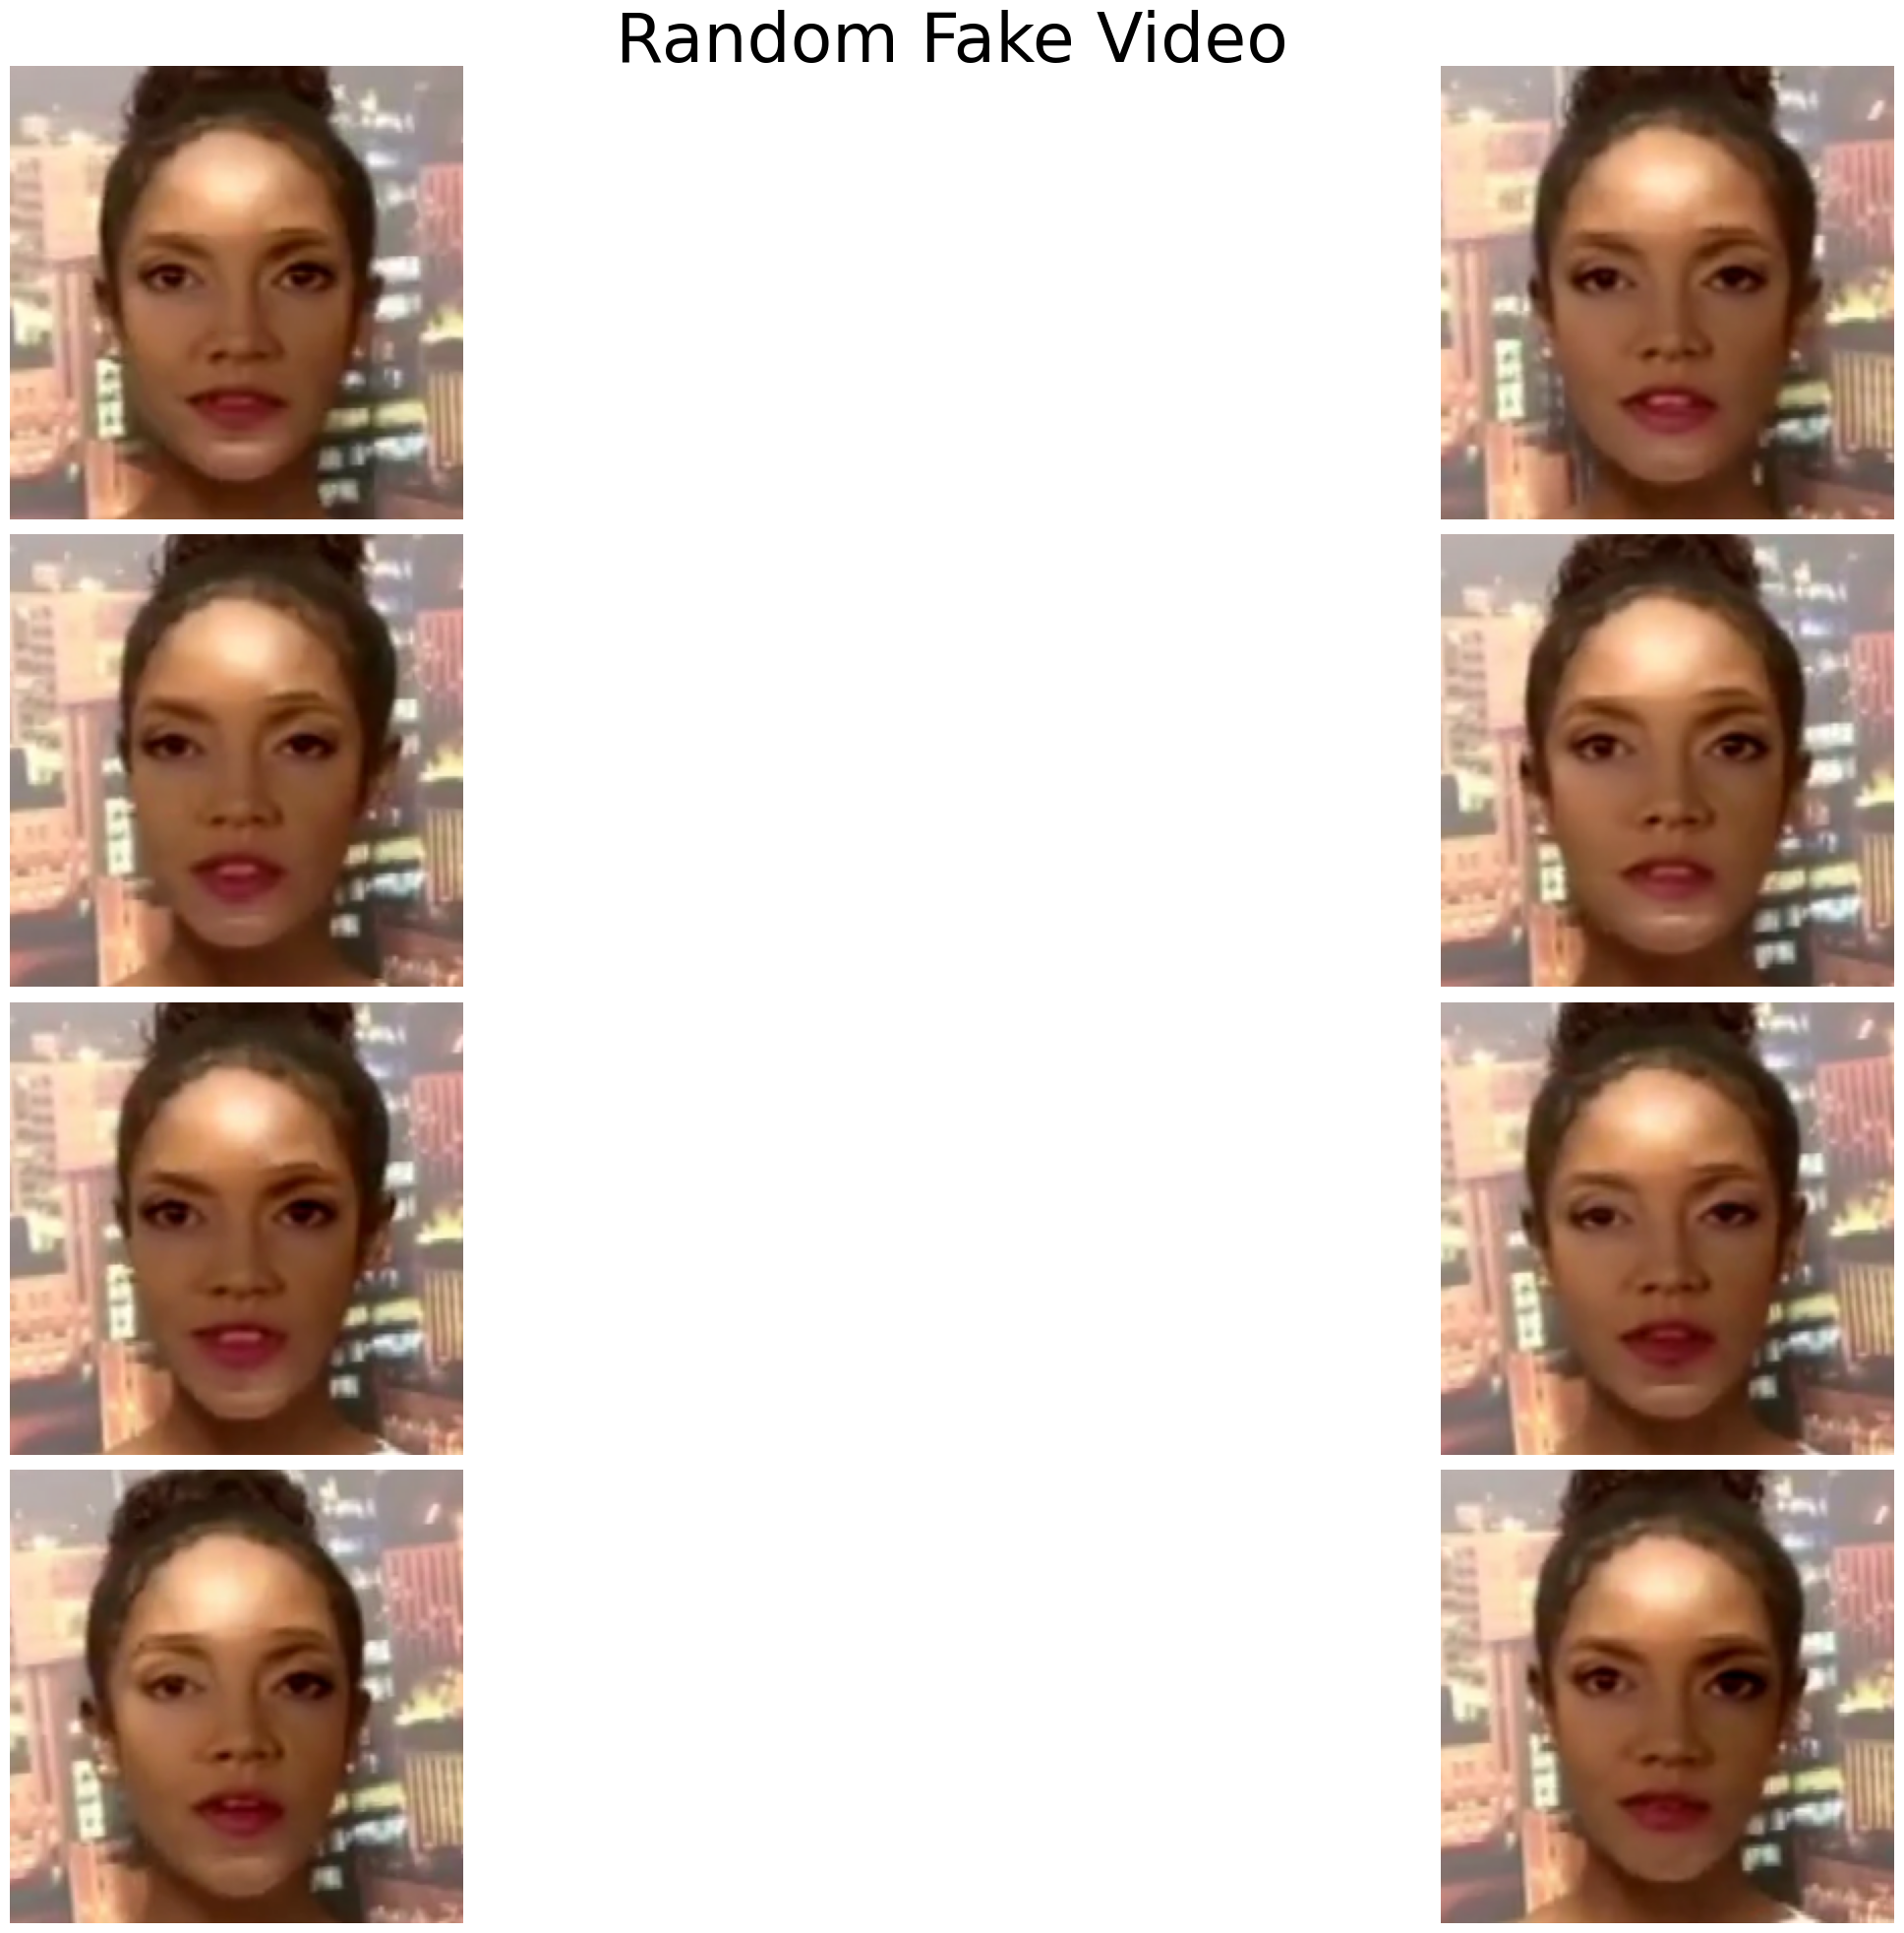

In [12]:
# Random fake example
idx = 0
example_path = videos[idx]

# its corresponding real video.
real_example = videos[4*N_DATA + (idx%N_DATA)]

fig, axs = plt.subplots(4, TOTAL_FRAMES // 4, figsize=(40, 20))
axs = axs.flatten()

for i, (frame, ax) in enumerate(zip(preprocess_video(example_path, TOTAL_FRAMES).numpy().transpose([0, 2, 3, 1]).astype(np.uint8), axs)):
    ax.imshow(frame)
    ax.axis('off')

fig.suptitle("Random Fake Video", fontsize=50)
plt.tight_layout()
plt.show()

In [13]:
# Getting the test set video paths.
fake_videos, real_videos = [], []

for part in range(10):
    data_part = TEST_DATA_DIR / f"dfdc_train_part_0{part}" / f"dfdc_train_part_{part}"
    meta_path = f"{data_part}/metadata.json"

    with open(meta_path, "r") as f:
        metadata = json.load(f)
    
        for video, info in metadata.items():
            assert info["label"] in ["FAKE", "REAL"]
    
            # No reason why the test set would be paired (each fake example has a real counterpart).
            # So classes are processed and picked independently.
            if info["label"] == "FAKE":
                fake_videos.append(data_part / video)
            else:
                real_videos.append(data_part / video)

# Sampling a random subset of the test data containing N_TEST real examples and N_TEST fake ones.
fake_indices = np.random.permutation(len(fake_videos))[:N_TEST]
real_indices = np.random.permutation(len(real_videos))[:N_TEST]
videos = [fake_videos[i] for i in fake_indices] + [real_videos[j] for j in real_indices]

test_frames = preprocess_and_write_frames(videos, ["fake", "real"], OUT_DIR, N_TEST)
y_test = torch.cat([torch.ones(TOTAL_FRAMES * N_TEST), torch.zeros(TOTAL_FRAMES * N_TEST)], axis = 0)

In [14]:
# Deleting the face detection model (freeing up GPU space).
import tensorflow as tf

tf.keras.backend.clear_session()
del RetinaFace.model
del retina_model

gc.collect()

37457

In [15]:
!nvidia-smi

Tue Jul  7 05:09:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             41W /   70W |   13877MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Torch Dataset

In [16]:
# # Tensorflow took the entirety of the first GPU by RetinaFace (even after clearing the session)
# DEVICE = torch.device("cuda:1" if torch.cuda.device_count() > 1 else "cpu")

In [17]:
class ImageDataset(Dataset):
    """
    PyTorch dataset for loading labeled frame files.

    Args:
        imgs: Sequence of image file paths.
        labels: Sequence of labels corresponding to ``imgs``.
        channels_first: If ``True``, returns images in ``(C, H, W)`` format;
            otherwise, ``(H, W, C)``. 
        transform: Optional transform applied to each image.
    """
    def __init__(self, imgs: List[Path], labels: torch.Tensor,
                 channels_first: bool = True, transform = None):
        super().__init__()
        self.imgs = imgs
        self.labels = labels
        self.transform = transform
        self.channels_first = channels_first

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[torch.Tensor, torch.Tensor]:
        img = cv2.imread(self.imgs[idx]).astype(np.float32) / 255.0

        if self.channels_first:
            img = np.transpose(img, (2, 0, 1))
        img = torch.tensor(img, dtype = torch.float16) #DTYPE

        if self.transform:
            img = self.transform(img)
    
        return  img, self.labels[idx]

clip_normalize = transforms.Normalize(
    (0.48145466, 0.4578275, 0.40821073),
    (0.26862954, 0.26130258, 0.27577711),)

data = ImageDataset(frames, y_train, transform = clip_normalize)
test_data = ImageDataset(test_frames, y_test, transform = clip_normalize)

In [18]:
# We have more than enough training data but not enough compute.
# Data augmentation remains in the back pocket for now.

val_split = 0.3
num_workers = 4

n_val   = int(len(data) * val_split) // TOTAL_FRAMES * TOTAL_FRAMES
n_train = len(data) - n_val

# Train, val split. They originate from the same data (FF++).
# The videos are pre-shuffled. Splitting train and val by video (not frame) to prevent leakage.
train_ds = Subset(data, list(range(n_train)))
val_ds = Subset(data, list(range(n_train + 1, len(data))))

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=num_workers)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers)

# Test data from DFDC-10.
test_loader = DataLoader(
    test_data, batch_size=TOTAL_FRAMES, shuffle=False,
    num_workers=num_workers)

## Model training

In [19]:
class L2Normalize(torch.nn.Module):
    """
    nn.Module wrapper for the L2Normalization from the functional API.
    """
    def __init__(self, dim: int = 1, eps: float = 1e-12):
        super(L2Normalize, self).__init__()
        self.dim = dim
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.nn.functional.normalize(x, p=2, dim=1, eps=self.eps)

class CLIPBinaryClassifier(torch.nn.Module):
    """
    Wraps a CLIP visual encoder with a binary classification head.
    Args:
        visual: Pretrained CLIP visual encoder.
    """
    def __init__(self, clip_model: torch.nn.Module):
        super().__init__()
        self.visual = clip_model

        for name, param in self.visual.named_parameters():
            param.requires_grad = "ln" in name
 
        embed_dim = self.visual.output_dim  # 1024 for ViT-L/14
        self.l2 = L2Normalize()
        self.linear = torch.nn.Linear(embed_dim, 1, dtype = DTYPE)
 
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.visual(images).float()
        l2 = self.l2(features)
        return self.linear(l2), l2

def load_clip(model_name: str, device = DEVICE) -> torch.nn.Module:
    """
    Loads the visual encoder from a pretrained CLIP model.

    Args:
        model_name: Name of the CLIP model to load.

    Returns:
        The CLIP visual encoder with its final projection layer removed.
    """
    # Taking only the visual model, we won't use their preprocess or the language model.
    clip_model = clip.load(model_name, device=device)[0].visual
    # Removing the final projection and updating output dim to exclude it.
    clip_model.proj = None
    clip_model.output_dim = clip_model.transformer.width
    return clip_model

clip_model = load_clip("ViT-L/14", device = DEVICE)
# Preparing CLIP is done on CPU to not have all loaded components on cuda.
# Then, our model is transfered to GPU.
model = CLIPBinaryClassifier(clip_model).to(DEVICE)

100%|████████████████████████████████████████| 890M/890M [00:08<00:00, 106MiB/s]


In [20]:
class CLIPLoss(torch.nn.Module):
    """
    Loss combining binary classification with embedding alignment and uniformity.
    Follows the Deepfake Detection paper.

    Args:
        alpha: Weight of the alignment loss.
        beta: Weight of the uniformity loss.
    """
    def __init__(self, alpha: float = 0.1, beta: float = 0.5):
        super().__init__()
        self.bce = torch.nn.BCEWithLogitsLoss()
        self.alpha = alpha
        self.beta = beta

    def _align(self, embeddings: torch.Tensor, labels: torch.Tensor):
        """
        Aligns samples with the same labels (1 to 1 and 0 to 0).
        """
        # Embeddings is 2D [B, emb_dim] and labels must be 1D [B, ]
        labels = labels.reshape((-1,))
        assert embeddings.size(0) == labels.size(-1)

        # GenD code. It was unclear what this does without the code.
        # [B, 1] == [1, B]
        # Broadcasts repeating the first labels along the columns and the latter across rows.
        labels_equal_mask = (labels[:, None] == labels[None, :]).triu(diagonal = 1).float()
        # Every (x, y) where x!=y and labels[x]==labels[y]==1.
        positive_indices = torch.nonzero(labels_equal_mask, as_tuple=False)

        if positive_indices.numel() == 0:
            return torch.tensor(0.0, device=embeddings.device)

        # Sum of squared difference across emb_dim to get the distance, mean across the batch.
        return ((embeddings[positive_indices[:, 0]] - embeddings[positive_indices[:, 1]])**2).sum(axis = 1).mean()

    def _uniform(self, embeddings: torch.Tensor):
        """
        Calculates the average squared distance between any two embeddings
        adjusted by a temperature t.
        """
        t = 2
        min_value = 1e-6
        return torch.pdist(embeddings, p=2).pow(2).mul(-t).exp().mean().clamp(min=min_value).log()

    def forward(self, outputs: Tuple[torch.Tensor, torch.Tensor], labels: torch.Tensor):
        out, norm = outputs
        return self.bce(out, labels) + self.alpha * self._align(norm, labels) + self.beta * self._uniform(norm)

In [21]:
class CosineCyclicWarmupLR(torch.optim.lr_scheduler._LRScheduler):
    """
    Learning rate scheduler with cyclic linear warm-up followed by cosine decay.

    Args:
        optimizer: Optimizer whose learning rate is scheduled.
        steps_per_epoch: Number of optimizer steps in one epoch.
        warmup_epochs: Number of warm-up epochs per cycle.
        cycle_epochs: Total number of epochs in each cycle.
        min_lr: Minimum learning rate.
        max_lr: Peak learning rate reached after warm-up.
        last_epoch: Index of the last completed step.

    Returns:
        A learning rate that increases linearly during warm-up and decays
        following a cosine schedule for the remainder of each cycle.
    """
    def __init__(
        self,
        optimizer: torch.optim.Optimizer,
        steps_per_epoch: int,
        warmup_epochs: float = 1.0,
        cycle_epochs: float = 10.0,
        min_lr: float = 1e-5,
        max_lr: float = 3e-4,
        last_epoch: int = -1,
    ):
        self.steps_per_epoch = steps_per_epoch
        self.warmup_steps = warmup_epochs * steps_per_epoch
        self.cycle_steps = cycle_epochs * steps_per_epoch
        self.decay_steps = self.cycle_steps - self.warmup_steps
        self.min_lr = min_lr
        self.max_lr = max_lr
        super().__init__(optimizer, last_epoch)
 
    def get_lr(self):
        step = self.last_epoch  # incremented once per .step() call
        cycle_step = step % self.cycle_steps
 
        if cycle_step < self.warmup_steps:
            # linear warm-up: 1e-5 -> 3e-4 over one epoch
            frac = cycle_step / self.warmup_steps
            lr = self.min_lr + (self.max_lr - self.min_lr) * frac
        else:
            # cosine decay: 3e-4 -> 1e-5 over the remaining nine epochs
            decay_step = cycle_step - self.warmup_steps
            frac = decay_step / self.decay_steps
            cos_factor = 0.5 * (1.0 + math.cos(math.pi * frac))
            lr = self.min_lr + (self.max_lr - self.min_lr) * cos_factor
 
        return [lr for _ in self.optimizer.param_groups]

In [22]:
# Training hyperparams
epochs = 5
lr = 3e-5
min_lr = 1e-6
ckpt = None #MODEL_CKPT

In [23]:
def train(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 10,
    lr: float = 3e-4,
    min_lr: float = 1e-5,
    device: str | None = None,
    alpha: float = 0.1,
    beta: float  = 0.5,
    start_from_ckpt: Path | str | None = None,
    retrain_ckpt: bool = False
) -> torch.nn.Module:
    """
    Train a CLIP ViT-L/14 binary classifier.
 
     Args:
        model: Model to train.
        train_loader: DataLoader for the training set.
        val_loader: DataLoader for the validation set.
        epochs: Number of training epochs.
        lr: Maximum learning rate.
        min_lr: Minimum learning rate for the scheduler.
        device: Device on which to run training.
        alpha: Weight of the alignment loss.
        beta: Weight of the uniformity loss.
        start_from_ckpt: Optional checkpoint to load before training.
        retrain_ckpt: If ``False``, returns the loaded checkpoint without further
            training.
    
    Returns:
        The best-performing model in evaluation mode.
    """
    print(f"Using device: {device}")
 
    criterion = CLIPLoss(alpha = alpha, beta = beta)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    steps_per_epoch = len(train_loader)
    scheduler = CosineCyclicWarmupLR(optimizer, steps_per_epoch, cycle_epochs = 10,
                    max_lr = lr, min_lr = min_lr)

    val_losses, val_accs, train_losses, train_accs = ([] for _ in range(4))
    best_val_loss = float("inf")
    best_state    = None

    if start_from_ckpt:
        ckpt = torch.load(start_from_ckpt)
        model.load_state_dict(ckpt)
        best_state  = model.state_dict()
        if not retrain_ckpt:
            return model.eval()
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_correct = 0
 
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)   # (B,) → (B, 1)
 
            optimizer.zero_grad()
            outputs, l2 = model(images)                            # (B, 1) in [0, 1]
            loss    = criterion((outputs, l2), labels)
    
            loss.backward()
            optimizer.step()
            scheduler.step()

            train_loss    += loss.item() * images.size(0)
            preds          = (outputs >= 0).float()
            train_correct += (preds == labels).sum().item()


 
        train_loss /= n_train
        train_acc   = train_correct / n_train
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
 
        model.eval()
        val_loss = 0.0
        val_correct = 0
 
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)
 
                outputs, l2 = model(images)
                loss        = criterion((outputs, l2), labels)
                
                val_loss   += loss.item() * images.size(0)
                preds       = (outputs >= 0.).float()
                val_correct += (preds == labels).sum().item()
 
        val_loss /= n_val
        val_acc   = val_correct / n_val
        val_losses.append(val_loss)
        val_accs.append(val_acc)
 
        print(
            f"Epoch {epoch:>3}/{epochs} | "
            f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
            f"Val   loss: {val_loss:.4f}, acc: {val_acc:.4f}"
        )
 
        # Save the best checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ✓ New best model saved (val_loss={best_val_loss:.4f})")
    
    if best_state is not None:
        torch.save(best_state, 'best_model.pt')
        model.load_state_dict(best_state)
    torch.save(model.state_dict(), f"epoch_{epoch}.pt")

    history = {"train_losses":train_losses,
        "train_accs": train_accs,
        "val_losses": val_losses,
        "val_accs": val_accs}

    return model.eval(), history


model, history = train(model, train_loader, val_loader, epochs = epochs, lr = lr,
        device = DEVICE, start_from_ckpt = ckpt, min_lr = min_lr)
print("Training done.")

Using device: cuda:1
Epoch   1/5 | Train loss: -0.4066, acc: 0.9169 | Val   loss: 0.4876, acc: 0.3332
  ✓ New best model saved (val_loss=0.4876)
Epoch   2/5 | Train loss: -0.9499, acc: 1.0000 | Val   loss: 0.5348, acc: 0.3332
Epoch   3/5 | Train loss: -1.3009, acc: 1.0000 | Val   loss: 0.6064, acc: 0.3332
Epoch   4/5 | Train loss: -1.4385, acc: 1.0000 | Val   loss: 0.7159, acc: 0.3332
Epoch   5/5 | Train loss: -1.5086, acc: 1.0000 | Val   loss: 0.8190, acc: 0.3332
Training done.


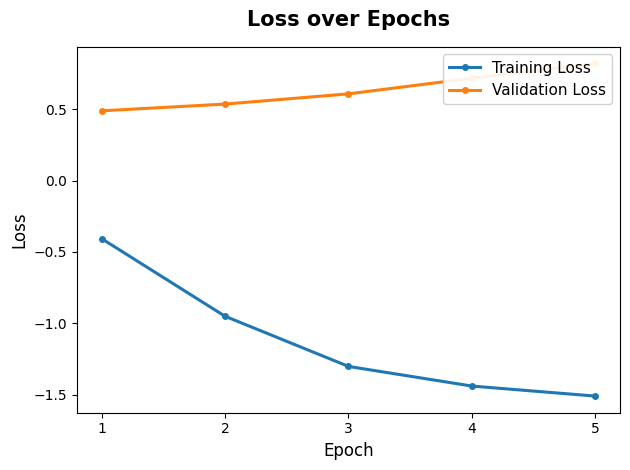

In [24]:
epochs_range = range(1, epochs + 1)

plt.plot(epochs_range, history["train_losses"], 
        label="Training Loss", linewidth=2.2, marker='o', markersize=4)
plt.plot(epochs_range, history["val_losses"], 
        label="Validation Loss", linewidth=2.2, marker='o', markersize=4)

plt.title("Loss over Epochs", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.legend(fontsize=11, frameon=True, framealpha=0.9, loc='upper right')
plt.xticks(list(epochs_range))

plt.tight_layout()
plt.show()

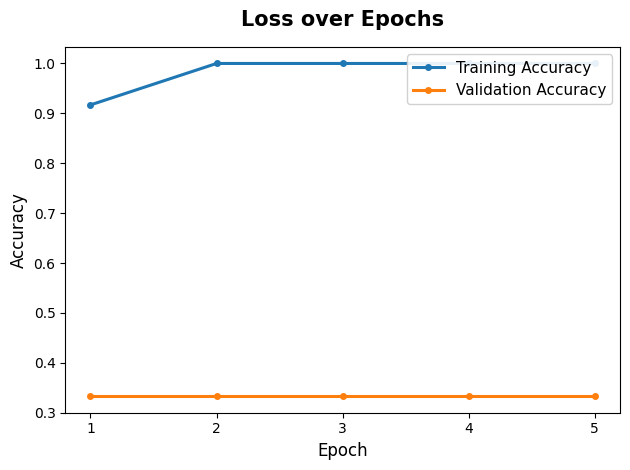

In [25]:
plt.plot(epochs_range, history["train_accs"], 
        label="Training Accuracy", linewidth=2.2, marker='o', markersize=4)
plt.plot(epochs_range, history["val_accs"], 
        label="Validation Accuracy", linewidth=2.2, marker='o', markersize=4)

plt.title("Loss over Epochs", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.legend(fontsize=11, frameon=True, framealpha=0.9, loc='upper right')
plt.xticks(list(epochs_range))

plt.tight_layout()
plt.show()

In [26]:
def scale_img(img: torch.Tensor| np.ndarray) -> torch.Tensor | np.ndarray:
    """
    Min-max normalizes an image to the range ``[0, 1]``.
    
    Args:
        img: Input image as a NumPy array or PyTorch tensor.
    
    Returns:
        The normalized image with the same type as the input.
    """
    mi, ma = img.min(), img.max()
    img = (img - mi) / (ma - mi)
    return img

def plot_predictions(imgs: torch.Tensor | np.ndarray , preds: torch.Tensor | np.ndarray,
                     labels: torch.Tensor | np.ndarray, fontsize: int = 20):
    """
    Displays a batch of images with their predicted fake probabilities and labels.
    
    Args:
        imgs: Batch of images in ``(N, C, H, W)`` format.
        preds: Predicted fake probabilities for each image.
        labels: Ground-truth binary labels (0 = real, 1 = fake).
        fontsize: Font size used for subplot titles.
    """
    imgs, preds, labels = (tens.detach().cpu().numpy().flatten() if not isinstance(tens, np.ndarray) else tens for tens in (imgs, preds, labels) )
    imgs = scale_img(imgs)
    y = min(4, imgs.shape[0] // 2) # Fails if batch is 1.
    fig, axs = plt.subplots(y, max(imgs.shape[0] // y, 2), figsize=(40, 20))
    axs = axs.flatten()
    
    for i in range(min(len(axs), len(labels))):
        img, pred, ax, label = imgs[i], preds[i], axs[i], labels[i]
        ax.imshow(np.transpose(img, [1, 2, 0]).astype(np.float32))
        ax.set_title(f"Predicted {pred*100:0.2f}% fake and is {"fake" if label else "real"}.", 
                    fontsize = fontsize)
        ax.axis("off")
    plt.show()

In [27]:
@torch.no_grad()
def predict_video(model: torch.nn.Module, video: torch.Tensor, device = DEVICE,
                  return_float = True) -> torch.Tensor | float:
    """
    Predicts the probability that a video is fake from its preprocessed frames.
    
    Args:
        model: Trained binary classification model.
        video: Tensor containing the video's preprocessed frames.
        device: Device on which to run inference.
        return_float: If ``True``, returns a Python ``float``; otherwise, returns
            a scalar tensor.
    
    Returns:
        The mean predicted fake probability across all frames.
    """

    video = video.to(device)
    out, _ = model(video)
    prob = torch.nn.functional.sigmoid(out).mean()
    if return_float:
        return prob.item()
    else:
        return prob

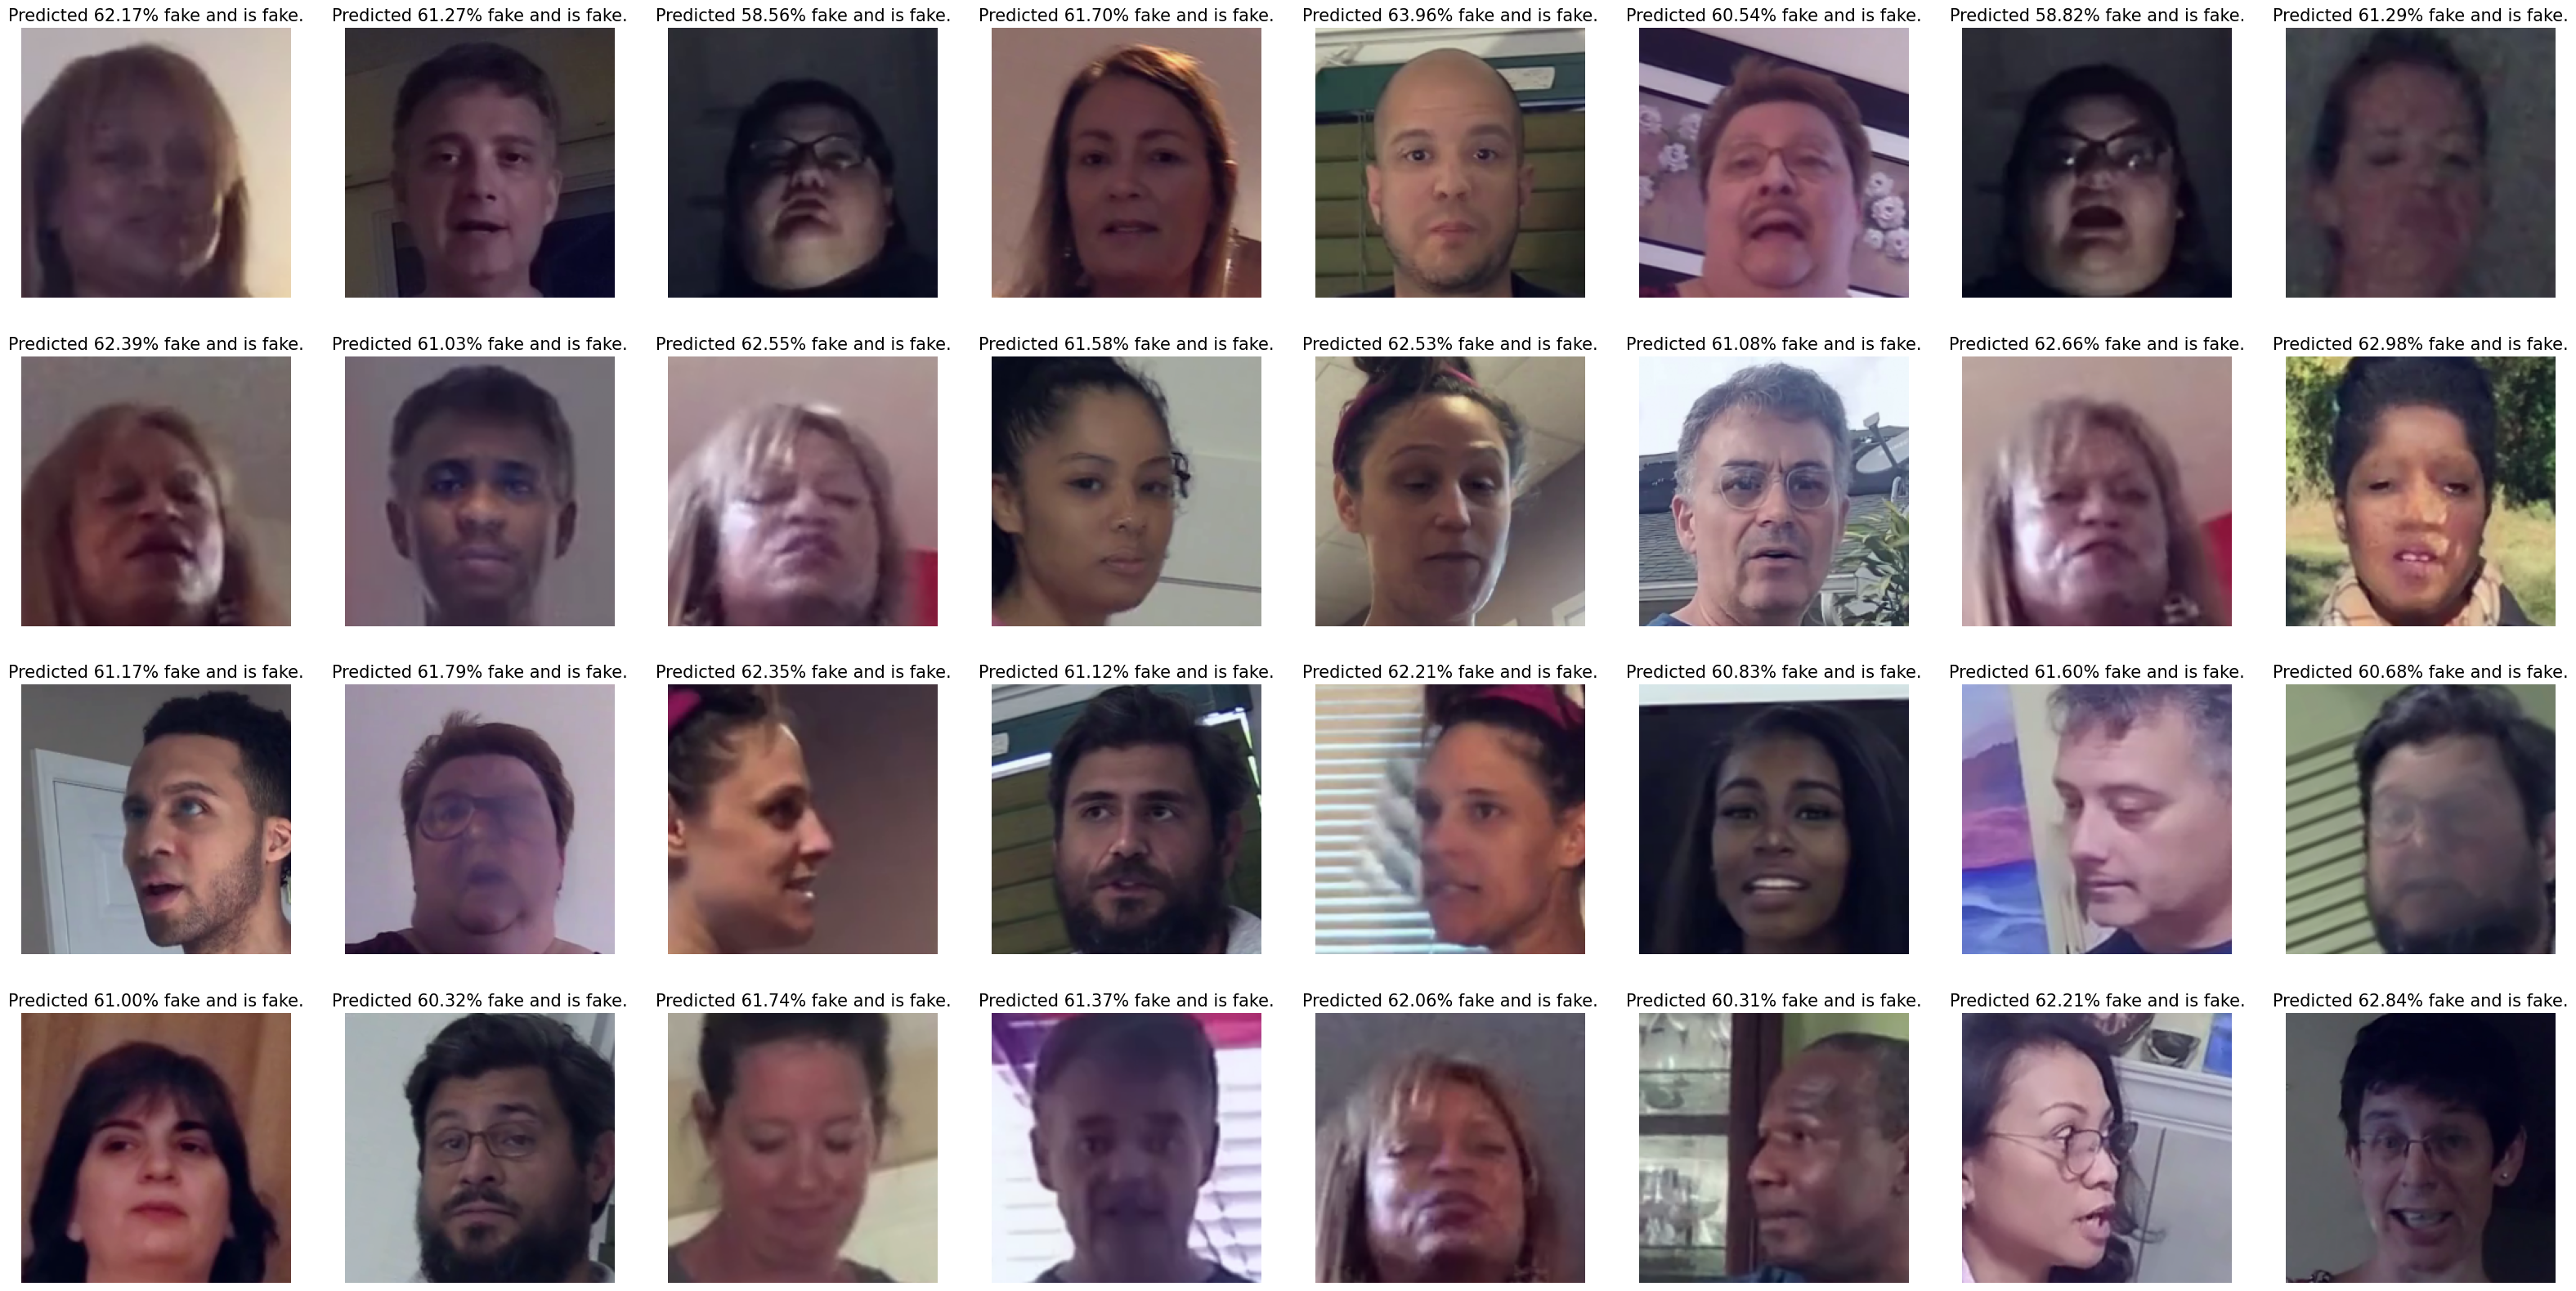

In [28]:
# Visualizing some videos from the test loader.
outs, images, labels = [], [], []
limit = 32
i = 1
for batch, y in test_loader:
    if i > limit:
        break
    outs.append(predict_video(model, batch))
    images.append(batch[0].cpu().numpy())
    labels.append(y[0])
    i += 1

images = scale_img(np.stack(images, axis = 0))
labels = np.stack(labels, axis = 0)
outs = np.stack(outs, axis = 0)
plot_predictions(images, outs, labels, fontsize = 15)

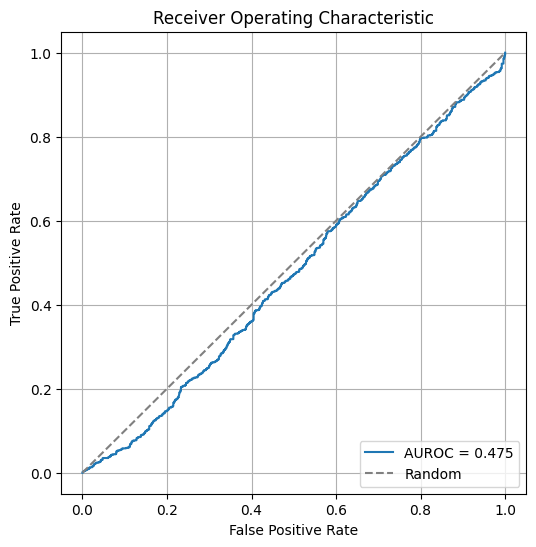

In [29]:
# Measuring the Area Under the Receiver Operating Characteristic Curve of the entire test set. 
auroc = AUROC(task = "binary")

preds, labels = [], []
for batch, y in test_loader:
    preds.append(predict_video(model, batch, return_float = False))
    labels.append(y[0])

preds = torch.stack(preds, axis = 0)
labels = torch.stack(labels, axis = 0).to(DEVICE)
roc_auc = auroc(preds, labels).item()

preds = preds.cpu().numpy()
labels = labels.cpu().numpy()

# Compute ROC curve
fpr, tpr, _ = roc_curve(labels, preds)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label = f"AUROC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()